# 1. 데이터 로드

패키지

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
from scipy.stats import norm, shapiro, kstest, probplot, jarque_bera
import plotly
import plotly.express as px
import nbformat

from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import gc

from collections import Counter

In [2]:
# 모델링 관련 패키지
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import xgboost as xgb
from xgboost.callback import EarlyStopping

import optuna

from sklearn.metrics import mean_squared_error

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


한글 패치

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 경로 (Windows 설치 위치)
font_path = "C:/Windows/Fonts/NanumGothic.ttf"
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family='Malgun Gothic')   # 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

# 피로도기반 인접행렬 만들기!

역 이름별로 숫자부여

In [4]:
in_pred = pd.read_csv(r"C:\Users\pc\Desktop\JB\졸업논문\연구기록\1. SARMA + GARCH 예측\SARMA + GARCH - 8시 승차인원 예측.csv", encoding = "cp949")
in_pred

,동대문_1호선,동묘앞_1호선,서울역_1호선,시청_1호선,신설동_1호선,제기동_1호선,종각_1호선,종로3가_1호선,종로5가_1호선,청량리.서울시립대입구._1호선,...,복정_8호선,산성_8호선,석촌_8호선,송파_8호선,수진_8호선,신흥_8호선,암사_8호선,잠실.송파구청._8호선,장지_8호선,천호.풍납토성._8호선
0,810.676688,514.268822,5469.545520,335.737172,1311.334782,1209.952741,349.668487,360.521715,383.729013,2314.030344,...,1468.211166,1267.457369,995.069374,1460.199313,851.909637,883.015385,3059.742151,450.191312,2093.703775,2255.574125
1,847.881346,590.049870,7012.732475,347.708267,1332.134725,1362.520372,384.447137,367.699449,397.214958,2485.844248,...,1511.045302,1337.960227,1018.786237,1502.183175,911.278714,904.699873,3480.505550,500.012580,2130.069124,2305.043965
2,859.008651,588.847299,6464.744799,365.490326,1365.984096,1380.674098,384.859568,379.126592,387.495852,2626.865554,...,1595.616728,1441.810179,1055.532954,1608.613798,940.437156,949.536361,3521.016475,493.221142,2221.553033,2415.939178
3,830.503502,496.082994,5387.535800,350.020567,1242.190347,1193.350059,357.399106,360.488765,392.834266,2210.384877,...,1303.564636,1239.205721,892.725463,1353.159565,819.810925,824.724770,2874.893642,439.488982,1892.412943,2079.970317
4,450.136900,235.152415,2653.472283,261.467156,483.841220,497.476044,271.326816,317.825333,272.044881,823.892208,...,434.802674,382.713690,295.840358,426.657695,353.051776,311.686438,930.819468,212.107605,619.173769,697.388536
5,409.700978,223.156919,1607.866841,246.692153,359.059973,339.288898,229.778836,280.246103,187.339966,594.843146,...,289.396248,260.890571,209.929470,287.197291,221.393263,201.495636,621.756223,141.031813,396.701307,460.926222
6,833.870912,521.893326,6749.052653,364.764502,1241.675024,1204.196255,366.686995,366.028940,369.046711,2256.152296,...,1332.108241,1187.948586,904.348240,1359.234755,842.815062,826.863886,2995.007340,448.441873,1875.019789,2061.317644


In [5]:
in_pred.columns

Index(['동대문_1호선', '동묘앞_1호선', '서울역_1호선', '시청_1호선', '신설동_1호선', '제기동_1호선',
       '종각_1호선', '종로3가_1호선', '종로5가_1호선', '청량리.서울시립대입구._1호선',
       ...
       '복정_8호선', '산성_8호선', '석촌_8호선', '송파_8호선', '수진_8호선', '신흥_8호선', '암사_8호선',
       '잠실.송파구청._8호선', '장지_8호선', '천호.풍납토성._8호선'],
      dtype='object', length=269)

In [20]:
# 역 이름을 숫자로 부여
for i, station in enumerate(in_pred.columns):
    print(f"{station} = {i}")

동대문_1호선 = 0
동묘앞_1호선 = 1
서울역_1호선 = 2
시청_1호선 = 3
신설동_1호선 = 4
제기동_1호선 = 5
종각_1호선 = 6
종로3가_1호선 = 7
종로5가_1호선 = 8
청량리.서울시립대입구._1호선 = 9
강남_2호선 = 10
강변.동서울터미널._2호선 = 11
건대입구_2호선 = 12
교대.법원.검찰청._2호선 = 13
구로디지털단지_2호선 = 14
구의.광진구청._2호선 = 15
낙성대.강감찬._2호선 = 16
당산_2호선 = 17
대림.구로구청._2호선 = 18
도림천_2호선 = 19
동대문역사문화공원.DDP._2호선 = 20
뚝섬_2호선 = 21
문래_2호선 = 22
방배_2호선 = 23
봉천_2호선 = 24
사당_2호선 = 25
삼성.무역센터._2호선 = 26
상왕십리_2호선 = 27
서울대입구.관악구청._2호선 = 28
서초_2호선 = 29
선릉_2호선 = 30
성수_2호선 = 31
시청_2호선 = 32
신답_2호선 = 33
신당_2호선 = 34
신대방_2호선 = 35
신도림_2호선 = 36
신림_2호선 = 37
신설동_2호선 = 38
신정네거리_2호선 = 39
신촌_2호선 = 40
아현_2호선 = 41
양천구청_2호선 = 42
역삼_2호선 = 43
영등포구청_2호선 = 44
왕십리.성동구청._2호선 = 45
용답_2호선 = 46
용두.동대문구청._2호선 = 47
을지로3가_2호선 = 48
을지로4가_2호선 = 49
을지로입구_2호선 = 50
이대_2호선 = 51
잠실.송파구청._2호선 = 52
잠실나루_2호선 = 53
잠실새내_2호선 = 54
종합운동장_2호선 = 55
충정로.경기대입구._2호선 = 56
한양대_2호선 = 57
합정_2호선 = 58
홍대입구_2호선 = 59
가락시장_3호선 = 60
경복궁.정부서울청사._3호선 = 61
경찰병원_3호선 = 62
고속터미널_3호선 = 63
교대.법원.검찰청._3호선 = 64
구파발_3호선 = 65
금호_3호선 = 66
남부터미널.예술의전당._3호선 = 67
녹번_3호선 = 68

In [6]:
INF = 10000           # 무한대 대신 충분히 큰 값
VERTEX_COUNT = 269    # 총 역의 개수

# 인접행렬 생성 (일단 다 INF로 채우기)
adj = [[INF for _ in range(VERTEX_COUNT)] for _ in range(VERTEX_COUNT)]

In [7]:
# 역 이름과 숫자를 매칭시키는 딕셔너리 생성
station_to_num = {station: i for i, station in enumerate(in_pred.columns)}
num_to_station = {i: station for i, station in enumerate(in_pred.columns)}
station_to_num['구산_6호선']
num_to_station[176]

'구산_6호선'

열차이용피로도지수, 가는데 걸리는시간 반영

In [8]:
# 열차이용피로도지수 불러오기
conjest = pd.read_csv(r"C:\Users\pc\Desktop\JB\졸업논문\연구기록\열차이용피로도지수.csv", encoding="utf-8-sig", index_col=0)
conjest

,요일구분,호선,역번호,출발역,상하구분,8시 혼잡도,xhat,y,열차이용피로도지수
0,평일,1호선,150,서울역_1호선,상선,0.8030,0.845364,0.644999,0.695182
1,평일,1호선,150,서울역_1호선,하선,0.3160,0.845364,0.644999,0.451682
2,평일,1호선,151,시청_1호선,상선,0.5495,0.486061,0.961477,0.325485
3,평일,1호선,151,시청_1호선,하선,0.3010,0.486061,0.961477,0.201235
4,평일,1호선,152,종각_1호선,상선,0.3090,0.641010,0.969343,0.281137
...,...,...,...,...,...,...,...,...,...
548,평일,8호선,2825,신흥_8호선,하선,0.1715,0.081058,0.247300,0.076819
549,평일,8호선,2826,수진_8호선,상선,0.1165,0.096487,0.373527,0.031788
550,평일,8호선,2826,수진_8호선,하선,0.1715,0.096487,0.373527,0.059288
551,평일,8호선,2827,모란_8호선,상선,0.0785,0.061585,0.527798,-0.035517


In [9]:
# 지하철역 순서 불러오기
subway_order = pd.read_csv(r"C:\Users\pc\Desktop\JB\졸업논문\데이터\지하철 노선순서 정리.csv", encoding="cp949")
subway_order.head(3)

,상선_1호선,하선_1호선,내선_2호선(1),외선_2호선(1),내선_2호선(2),외선_2호선(2),내선_2호선(3),외선_2호선(3),상선_3호선,하선_3호선,...,하선_5호선(2),상선_5호선(3),하선_5호선(3),상선_6호선,하선_6호선(1),하선_6호선(2),상선_7호선,하선_7호선,상선_8호선,하선_8호선
0,서울역_1호선,청량리.서울시립대입구._1호선,성수_2호선,성수_2호선,성수E_2호선,신설동_2호선,신도림E_2호선,신정네거리_2호선,오금_3호선,지축_3호선,...,강동_5호선,마천_5호선,강동_5호선,봉화산.서울의료원._6호선,응암_6호선,응암S_6호선,온수.성공회대입구._7호선,장암_7호선,모란_8호선,암사_8호선
1,시청_1호선,제기동_1호선,건대입구_2호선,뚝섬_2호선,용답_2호선,용두.동대문구청._2호선,도림천_2호선,양천구청_2호선,경찰병원_3호선,구파발_3호선,...,길동_5호선,거여_5호선,둔촌동_5호선,화랑대.서울여대입구._6호선,새절.신사._6호선,역촌_6호선,천왕_7호선,도봉산_7호선,수진_8호선,천호.풍납토성._8호선
2,종각_1호선,신설동_1호선,구의.광진구청._2호선,한양대_2호선,신답_2호선,신답_2호선,양천구청_2호선,도림천_2호선,가락시장_3호선,연신내_3호선,...,굽은다리.강동구민회관앞._5호선,개롱_5호선,올림픽공원.한국체대._5호선,태릉입구_6호선,증산.명지대앞._6호선,불광_6호선,광명사거리_7호선,수락산_7호선,신흥_8호선,강동구청_8호선


In [10]:
INF = 100000

# 역 이름 전체 리스트
stations = [x for x in pd.unique(subway_order.values.ravel()) if pd.notna(x)]

# 역 이름과 숫자를 매칭시키는 딕셔너리 생성
station_to_num = {station: i for i, station in enumerate(stations)}
num_to_station = {i: station for i, station in enumerate(stations)}

n = len(stations)

# 인접행렬 생성
adj = np.full((n,n), INF, dtype=float)

# 자기 자신은 0
for i in range(n):
    adj[i,i] = 0

In [11]:
# 상선 처리 (6호선만 해봄)
up_list = subway_order['상선_6호선'].dropna().tolist()

for i in range(len(up_list)-1):

    cur_station = up_list[i]
    next_station = up_list[i+1]

    if cur_station in conjest['출발역'].unique().tolist():

        # 현재역 상선 피로도
        fatigue = conjest[
            (conjest['출발역']==cur_station) &
            (conjest['상하구분']=="상선")
        ]['열차이용피로도지수'].values[0]

        i_idx = station_to_num[cur_station]
        j_idx = station_to_num[next_station]

        adj[i_idx][j_idx] = fatigue

    else:
        i_idx = station_to_num[cur_station]
        j_idx = station_to_num[next_station]

        adj[i_idx][j_idx] = 44444

In [12]:
for line in subway_order.columns:
    print(line.split('_')[0])

상선
하선
내선
외선
내선
외선
내선
외선
상선
하선
상선
하선
상선
하선
상선
하선
상선
하선
상선
하선
하선
상선
하선
상선
하선


In [13]:
# 전체 다 해보자
for line in subway_order.columns:
    up_list = subway_order[line].dropna().tolist()     # line = '내선_2호선(2)' 이런식...

    for i in range(len(up_list)-1):

        cur_station = up_list[i]
        next_station = up_list[i+1]

        if cur_station in conjest['출발역'].unique().tolist():

            # 현재역 상선 피로도
            fatigue = conjest[
                (conjest['출발역']==cur_station) &
                (conjest['상하구분']==line.split('_')[0])      # line.split('_')[0] = '내선' 이런식...
            ]['열차이용피로도지수'].values[0]

            i_idx = station_to_num[cur_station]
            j_idx = station_to_num[next_station]

            adj[i_idx][j_idx] = fatigue

        else:
            i_idx = station_to_num[cur_station]
            j_idx = station_to_num[next_station]

            adj[i_idx][j_idx] = 44444


# 이상한 역 직접 수정하기
adj[station_to_num['연신내_6호선']][station_to_num['구산_6호선']] = adj[station_to_num['독바위_6호선']][station_to_num['연신내_6호선']]
adj[station_to_num['삼각지_4호선']][station_to_num['신용산_4호선']] = adj[station_to_num['숙대입구.갈월._4호선']][station_to_num['삼각지_4호선']]
adj[station_to_num['삼각지_4호선']][station_to_num['숙대입구.갈월._4호선']] = adj[station_to_num['신용산_4호선']][station_to_num['삼각지_4호선']]
adj[station_to_num['충무로_3호선']][station_to_num['을지로3가_3호선']] = adj[station_to_num['동대입구_3호선']][station_to_num['충무로_3호선']]
adj[station_to_num['충무로_3호선']][station_to_num['동대입구_3호선']] = adj[station_to_num['을지로3가_3호선']][station_to_num['충무로_3호선']]
adj[station_to_num['삼각지_6호선']][station_to_num['효창공원앞_6호선']] = adj[station_to_num['녹사평.용산구청._6호선']][station_to_num['삼각지_6호선']]
adj[station_to_num['삼각지_6호선']][station_to_num['녹사평.용산구청._6호선']] = adj[station_to_num['효창공원앞_6호선']][station_to_num['삼각지_6호선']]

In [14]:
# 이상한 특이역 있나 확인
idx = np.where(adj == 44444)

for i, j in zip(idx[0], idx[1]):
    print(num_to_station[i], num_to_station[j])

In [15]:
print(adj[station_to_num['한양대_2호선']][station_to_num['왕십리.성동구청._2호선']])
print(adj[station_to_num['왕십리.성동구청._2호선']][station_to_num['한양대_2호선']])

0.085740514
0.323756013


호선구분 없애고 합치기

In [18]:
# 호선 없애고 합치기
simple_stations = list(dict.fromkeys(station.split('_')[0] for station in stations))
len(simple_stations)

241

In [19]:
simple_station_to_num = {station: i for i, station in enumerate(simple_stations)}
simple_num_to_station = {i: station for station, i in simple_station_to_num.items()}

n_simple = len(simple_stations)
simple_adj = np.full((n_simple, n_simple), INF, dtype=float)

# 자기 자신은 0
for i in range(n_simple):
    simple_adj[i, i] = 0.0

# 호선까지 포함된 모든 역을 다 돌면서 인접한 역 사이에는 피로도지수 값 가져오기
for i in range(len(stations)):
    for j in range(len(stations)):
        value = adj[i][j]     # 각 값마다의 피로도지수

        # 연결 없는 값은 굳이 복사 안 해도 됨
        if value == INF:
            continue

        simple_i = stations[i].split('_')[0]
        simple_j = stations[j].split('_')[0]

        si = simple_station_to_num[simple_i]
        sj = simple_station_to_num[simple_j]

        simple_adj[si][sj] = value

In [20]:
# 응암S같은거 없애기
simple_adj[simple_station_to_num['성수']][simple_station_to_num['용답']] = simple_adj[simple_station_to_num['성수E']][simple_station_to_num['용답']]
simple_adj[simple_station_to_num['용답']][simple_station_to_num['성수']] = simple_adj[simple_station_to_num['용답']][simple_station_to_num['성수E']]

simple_adj[simple_station_to_num['신도림']][simple_station_to_num['도림천']] = simple_adj[simple_station_to_num['신도림E']][simple_station_to_num['도림천']]
simple_adj[simple_station_to_num['도림천']][simple_station_to_num['신도림']] = simple_adj[simple_station_to_num['도림천']][simple_station_to_num['신도림E']]

simple_adj[simple_station_to_num['응암']][simple_station_to_num['역촌']] = simple_adj[simple_station_to_num['응암S']][simple_station_to_num['역촌']]

In [21]:
# 응암S같은거 없애기
remove_stations = ['성수E', '신도림E', '응암S']

# 삭제할 index 찾기
remove_idx = [simple_stations.index(s) for s in remove_stations if s in simple_stations]

# 행렬에서 삭제
simple_adj = np.delete(simple_adj, remove_idx, axis=0)
simple_adj = np.delete(simple_adj, remove_idx, axis=1)

# 리스트에서 삭제
simple_stations = [s for s in simple_stations if s not in remove_stations]

# 인덱싱도 다시 하기
simple_station_to_num = {s:i for i,s in enumerate(simple_stations)}
simple_num_to_station = {i:s for i,s in enumerate(simple_stations)}

In [23]:
simple_adj

array([[0.00000000e+00, 1.00000000e+05, 1.00000000e+05, ...,
        1.00000000e+05, 1.00000000e+05, 1.00000000e+05],
       [1.00000000e+05, 0.00000000e+00, 1.00000000e+05, ...,
        1.00000000e+05, 1.00000000e+05, 1.00000000e+05],
       [1.00000000e+05, 1.00000000e+05, 0.00000000e+00, ...,
        1.00000000e+05, 1.00000000e+05, 1.00000000e+05],
       ...,
       [1.00000000e+05, 1.00000000e+05, 1.00000000e+05, ...,
        0.00000000e+00, 1.34867199e-01, 1.00000000e+05],
       [1.00000000e+05, 1.00000000e+05, 1.00000000e+05, ...,
        4.31066270e-01, 0.00000000e+00, 1.00000000e+05],
       [1.00000000e+05, 1.00000000e+05, 1.00000000e+05, ...,
        1.00000000e+05, 1.00000000e+05, 0.00000000e+00]], shape=(238, 238))

In [253]:
# csv로 내보내기
simple_adj_df = pd.DataFrame(simple_adj, index=simple_stations, columns=simple_stations)

simple_adj_df.to_csv("simple_adj.csv", encoding="utf-8-sig")

In [262]:
simple_station_to_num['어린이대공원.세종대.']

224

# 지도로 mapping해서 표현해보기

In [24]:
# csv 불러와서 행렬로 만들기
simple_adj_df = pd.read_csv(r"C:\Users\pc\Desktop\JB\졸업논문\연구기록\simple_adj.csv", encoding="utf-8-sig", index_col=0)

simple_adj = simple_adj_df.values
simple_stations = simple_adj_df.index.tolist()

simple_station_to_num = {station: i for i, station in enumerate(simple_stations)}
simple_num_to_station = {i: station for station, i in simple_station_to_num.items()}

simple_adj[simple_station_to_num['구산']][simple_station_to_num['응암']]

np.float64(0.259831352)

In [25]:
subway_crd = pd.read_csv(r"C:\Users\pc\Desktop\JB\졸업논문\데이터\지하철역별 좌표 정리.csv", encoding="utf-8-sig")
subway_crd['역이름'] = subway_crd['역이름'].str.replace(r'[()·]', '.', regex=True)
subway_crd

,역이름,y,x,호선,geometry
0,동대문,37.571420,127.009745,"[1, 4]",POINT (127.009745 37.57142)
1,동묘앞,37.572627,127.016429,"[1, 6]",POINT (127.016429 37.572627)
2,서울역,37.554648,126.972559,"[1, 4]",POINT (126.972559 37.554648)
3,시청,37.564718,126.977108,"[1, 2]",POINT (126.977108 37.564718)
4,신설동,37.575297,127.025087,"[1, 2]",POINT (127.025087 37.575297)
...,...,...,...,...,...
244,석촌고분,37.503800,127.096700,[9],POINT (127.0967 37.5038)
245,송파나루,37.508880,127.112183,[9],POINT (127.112183 37.50888)
246,한성백제,37.516078,127.116500,[9],POINT (127.1165 37.516078)
247,둔촌오륜,37.519600,127.138100,[9],POINT (127.1381 37.5196)


In [26]:
print(len(simple_stations))
print(len(subway_crd['역이름']))

238
249


In [27]:
missing_stations = [
    s for s in simple_stations
    if s not in set(subway_crd['역이름'])
]

print(missing_stations)

[]


In [28]:
missing_stations = [
    s for s in subway_crd['역이름']
    if s not in set(simple_stations)
]

print(missing_stations)

['당고개', '언주', '선정릉', '삼성중앙', '봉은사', '삼전', '석촌고분', '송파나루', '한성백제', '둔촌오륜', '중앙보훈병원']


In [29]:
# 11개 행 삭제
subway_crd_gdf = subway_crd[subway_crd['역이름'].isin(simple_stations)]

# 거리기반 인접행렬 만들기!

In [103]:
n_simple = len(simple_stations)
distance_adj = np.full((n_simple, n_simple), INF, dtype=float)

print(distance_adj.shape)
print(len(simple_stations))

(238, 238)
238


In [104]:
distance_adj[simple_station_to_num['신촌']][simple_station_to_num['이대']]
distance_adj[simple_station_to_num['신촌']][simple_station_to_num['한양대']]

np.float64(100000.0)

In [105]:
subway_crd_gdf

,역이름,y,x,호선,geometry
0,동대문,37.571420,127.009745,"[1, 4]",POINT (127.009745 37.57142)
1,동묘앞,37.572627,127.016429,"[1, 6]",POINT (127.016429 37.572627)
2,서울역,37.554648,126.972559,"[1, 4]",POINT (126.972559 37.554648)
3,시청,37.564718,126.977108,"[1, 2]",POINT (126.977108 37.564718)
4,신설동,37.575297,127.025087,"[1, 2]",POINT (127.025087 37.575297)
...,...,...,...,...,...
234,송파,37.499703,127.112183,[8],POINT (127.112183 37.499703)
235,수진,37.437428,127.140722,[8],POINT (127.140722 37.437428)
236,신흥,37.440918,127.147564,[8],POINT (127.147564 37.440918)
237,암사,37.550210,127.127562,[8],POINT (127.127562 37.55021)


In [106]:
from haversine import haversine

for i in range(len(simple_stations)):
    i_station = simple_num_to_station[i]
    i_data = subway_crd_gdf[subway_crd_gdf['역이름'] == i_station][['y','x']].values[0]
    i_crd = (i_data[0], i_data[1])

    for j in range(len(simple_stations)):
        value = simple_adj[i][j]     # 각 값마다의 피로도지수

        # 연결 없는 값은 굳이 복사 안 해도 됨
        if value == INF:
            continue
        
        j_station = simple_num_to_station[j]
        j_data = subway_crd_gdf[subway_crd_gdf['역이름'] == j_station][['y','x']].values[0]
        j_crd = (j_data[0], j_data[1])

        dist = haversine(i_crd, j_crd)

        distance_adj[i][j] = dist

In [107]:
print(distance_adj[simple_station_to_num['홍대입구']][simple_station_to_num['합정']])

1.3386119500829587


In [123]:
cnt = 0
for i in range(len(simple_stations)):
    for j in range(len(simple_stations)):
        if simple_adj[i][j] != INF and simple_adj[i][j] != 0:
            cnt = cnt + 1

cnt

526

최솟값과 최댓값 찾은 후 정규화

In [113]:
# 최솟값과 최댓값 찾은 후 정규화
arr = np.array(distance_adj)

# 100000 제외
filtered = arr[(arr != INF)]

# 최솟값, 최댓값
min_val = filtered.min()
max_val = filtered.max()

for i in range(len(simple_stations)):
    for j in range(len(simple_stations)):
        if distance_adj[i][j] != INF and distance_adj[i][j] != 0:
            distance_adj[i][j] = (distance_adj[i][j] - min_val) / (max_val - min_val)

In [ ]:
# 자기자신과의 거리는 0
print(distance_adj[simple_station_to_num['홍대입구']][simple_station_to_num['홍대입구']])

0.0


In [115]:
print(distance_adj[simple_station_to_num['홍대입구']][simple_station_to_num['합정']])

0.6111465682809806


In [116]:
# 최솟값과 최댓값 찾은 후 정규화
arr = np.array(distance_adj)

# 100000 제외
filtered = arr[(arr != INF) & (arr != 0)]

# 최솟값, 최댓값
min_val = filtered.min()
max_val = filtered.max()

print("최솟값:", min_val)
print("최댓값:", max_val)

최솟값: 0.23128023365051864
최댓값: 1.0


In [117]:
# 그 최솟값이 있는 위치 찾기
idx = np.where(arr == min_val)

print(idx)  # (행 index들, 열 index들)

print(simple_num_to_station[19])
print(simple_num_to_station[154])

print(distance_adj[simple_station_to_num['시청']][simple_station_to_num['을지로입구']])

(array([ 19, 154]), array([154,  19]))
시청
을지로입구
0.23128023365051864


In [120]:
# 그 최솟값이 있는 위치 찾기
idx = np.where(arr == max_val)

print(idx)  # (행 index들, 열 index들)

print(simple_num_to_station[69])
print(simple_num_to_station[89])

print(distance_adj[simple_station_to_num['동작.현충원.']][simple_station_to_num['이촌.국립중앙박물관.']])

(array([69, 89]), array([89, 69]))
동작.현충원.
이촌.국립중앙박물관.
1.0


In [124]:
# csv로 내보내기
distance_adj_df = pd.DataFrame(distance_adj, index=simple_stations, columns=simple_stations)

distance_adj_df.to_csv("distance_adj.csv", encoding="utf-8-sig")

In [ ]:
# 필요한 라이브러리
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

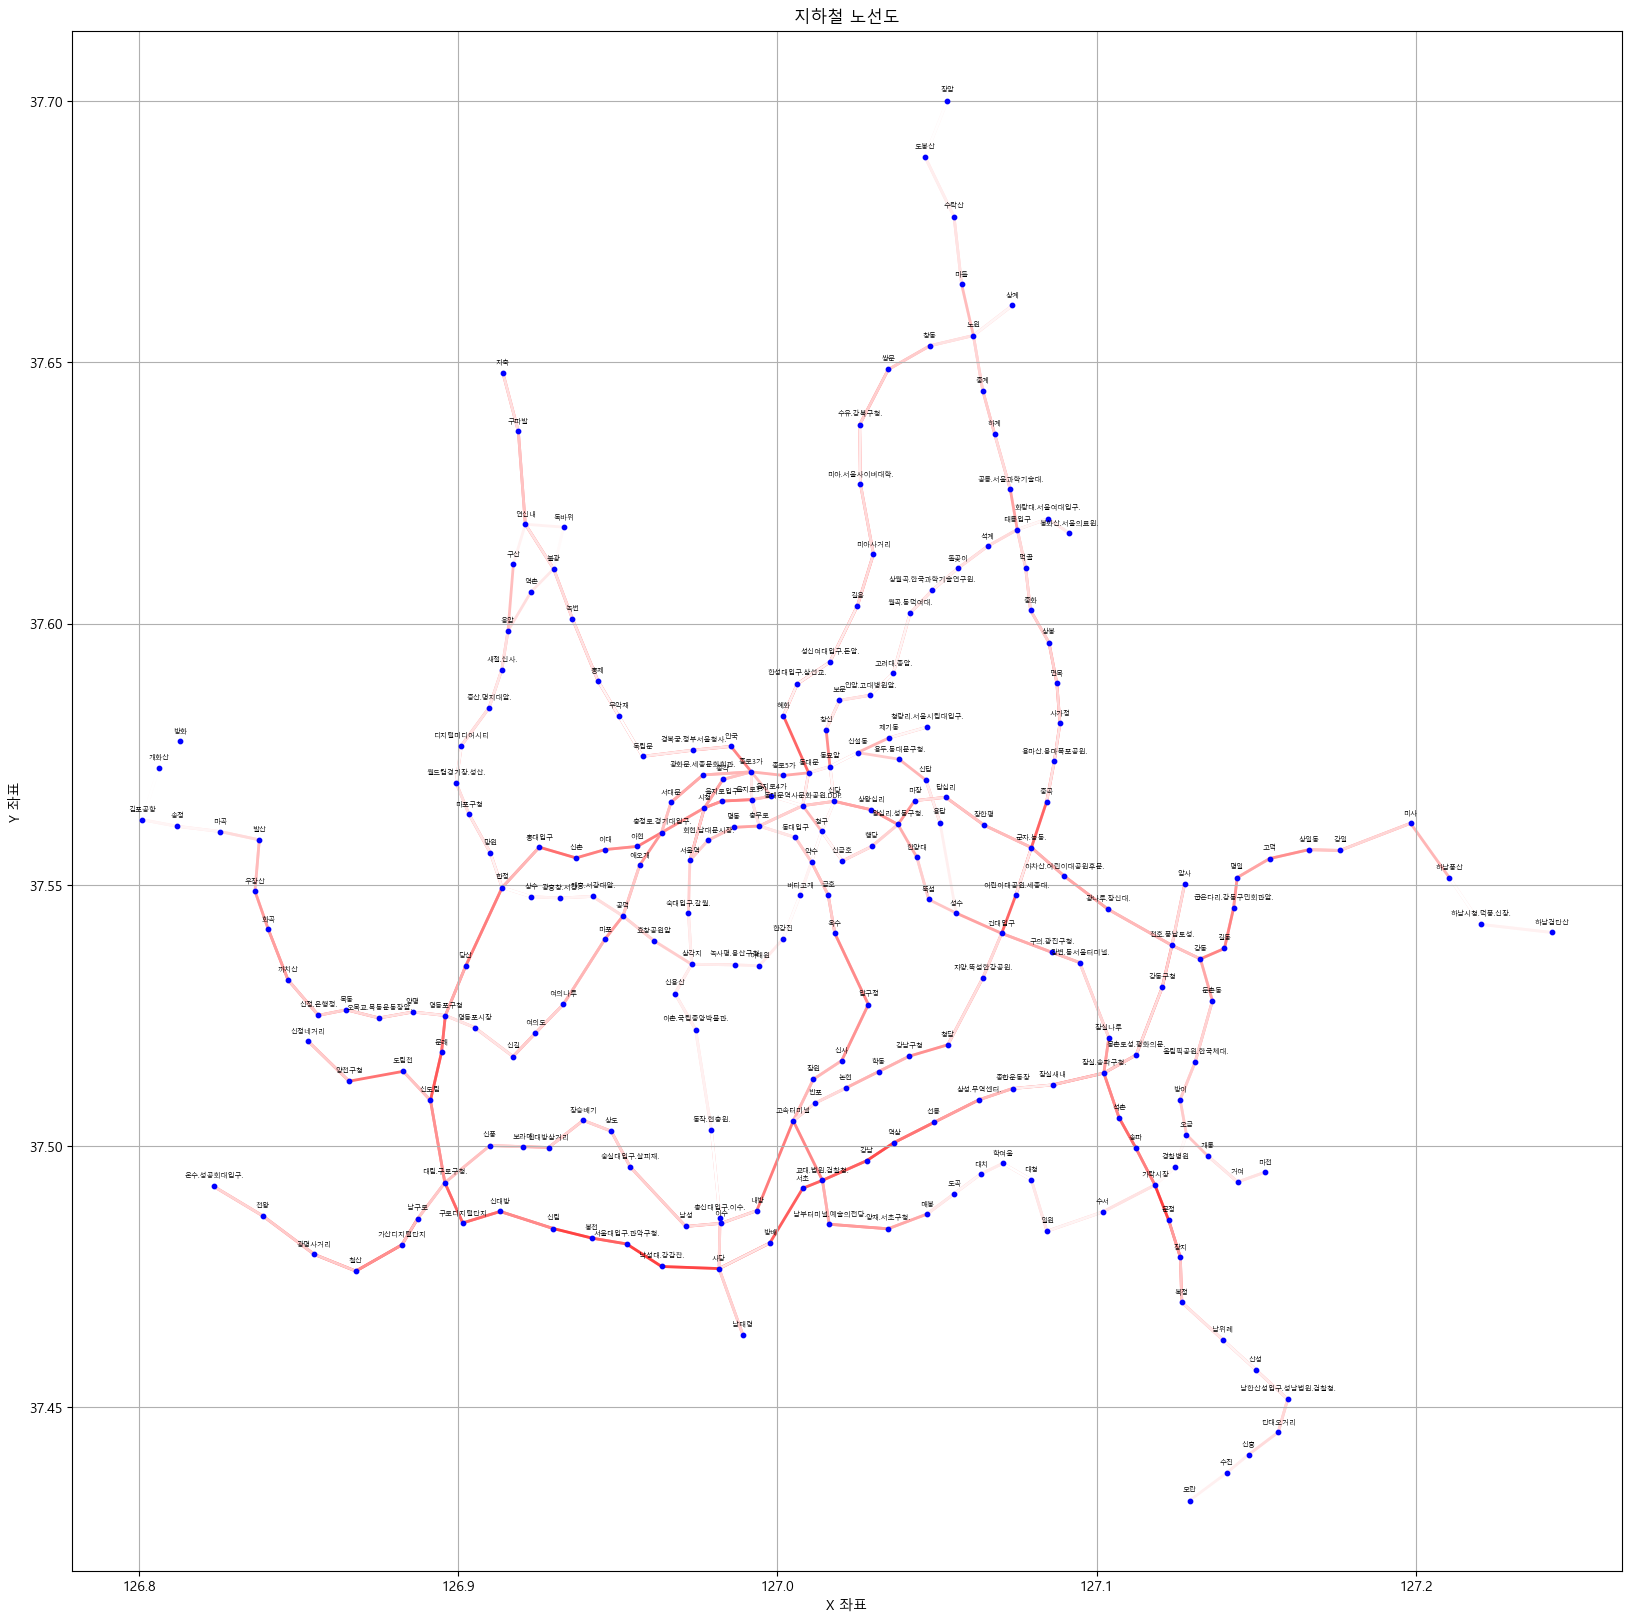

In [ ]:
# 맵핑 plot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(20,20))

# 색상맵
colors = [(1,1,1),(1,0,0)]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_red", colors, N=256)
norm = mcolors.Normalize(vmin=0, vmax=1)  # 피로도 범위에 맞게 수정 가능

n = simple_adj.shape[0]

for i in range(n):
    for j in range(n):

        value = simple_adj[i][j]

        if value != INF and i != j:

            start = simple_stations[i]
            end = simple_stations[j]

            if start in subway_crd_gdf['역이름'].values and end in subway_crd_gdf['역이름'].values:

                x_values = [
                    subway_crd_gdf.loc[subway_crd_gdf['역이름']==start,'x'].values[0],
                    subway_crd_gdf.loc[subway_crd_gdf['역이름']==end,'x'].values[0]
                ]

                y_values = [
                    subway_crd_gdf.loc[subway_crd_gdf['역이름']==start,'y'].values[0],
                    subway_crd_gdf.loc[subway_crd_gdf['역이름']==end,'y'].values[0]
                ]

                color = cmap(norm(value))

                plt.plot(x_values, y_values, color=color, linewidth=2, zorder=1)


# 전체 역 점 표시
plt.scatter(subway_crd_gdf['x'], subway_crd_gdf['y'], c='blue', s=10, zorder=2)

# 역 이름 표시
for x, y, name in zip(subway_crd_gdf['x'], subway_crd_gdf['y'], subway_crd_gdf['역이름']):
    plt.annotate(
        name,
        (x, y),
        xytext=(0,5),
        textcoords='offset points',
        fontsize=5,
        ha='center',
        va='bottom'
    )

plt.xlabel('X 좌표')
plt.ylabel('Y 좌표')
plt.title('지하철 노선도')
plt.grid(True)

plt.savefig("지하철_network.png", dpi=300, bbox_inches='tight')

plt.show()